# [기초-실습] 통계 101×데이터 분석: (7장) 싱관과 회귀

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## ⚙️ 환경 준비

### 1단계 · 한글 폰트 설치

- 그래프에 한글이 깨지지 않도록 나눔 폰트를 설치합니다.

- 실행 후 **[런타임] - [세션 다시 시작]**을 한 번 눌러야 폰트가 적용됩니다.

In [1]:
# 구글 코랩 환경에서 한글 폰트 설치 및 설정하기
# 필요시 아래 코드 실행 후, [런타임] - [세션 다시 시작] 후 셀을 다시 실행하세요.
!pip install statsmodels
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
'rm'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


### 2단계 · 라이브러리 불러오기

- 이번 실습에서 쓰는 도구입니다. **한 번만 실행**해 두면 끝까지 사용합니다.

- `smf`는 회귀식을 `'y ~ x'` 형태로 쓰는 모듈, `het_breuschpagan`은 등분산 검정 함수입니다.

In [2]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

## 문제 1 · 펭귄의 부리는 길수록 두꺼울까?

`난이도 하` · `예상 15분`

**📖 상황**

- 남극 팔머 기지에서 측정한 펭귄 344마리의 신체 데이터(`penguins`)를 사용합니다.

- 부리 길이(`bill_length_mm`)와 부리 두께(`bill_depth_mm`)가 함께 어떻게 움직이는지 봅니다.

- 그런데 이 데이터에는 **세 종(Adelie·Chinstrap·Gentoo)이 섞여 있습니다.**
  전체를 뭉쳐서 볼 때와 집단을 나눠서 볼 때 **결론이 정반대로 뒤집히는 일**이 실제로 일어납니다.

**🎯 이 문제로 배우는 것**

- 상관계수를 계산하기 **전에** 산점도를 먼저 그려야 하는 이유를, 숫자로 직접 확인합니다.

In [3]:
# 문제 1 · 데이터 준비 — 실행만 하세요
penguins = sns.load_dataset('penguins')

print("데이터 크기:", penguins.shape)
print("\n종별 개체 수:")
print(penguins['species'].value_counts())
print("\n결측치 개수:")
print(penguins.isna().sum())

penguins.head()

데이터 크기: (344, 7)

종별 개체 수:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

결측치 개수:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Q1 · 산점도로 두 변수의 관계를 그려 봅시다

- 가로축 `bill_length_mm`, 세로축 `bill_depth_mm`로 산점도를 그리세요.

- 그래프 제목과 축 라벨을 한글로 알아보기 쉽게 설정하세요.

- `💡 힌트` `sns.scatterplot(data=..., x=..., y=...)` / `plt.title()`, `plt.xlabel()`, `plt.ylabel()`

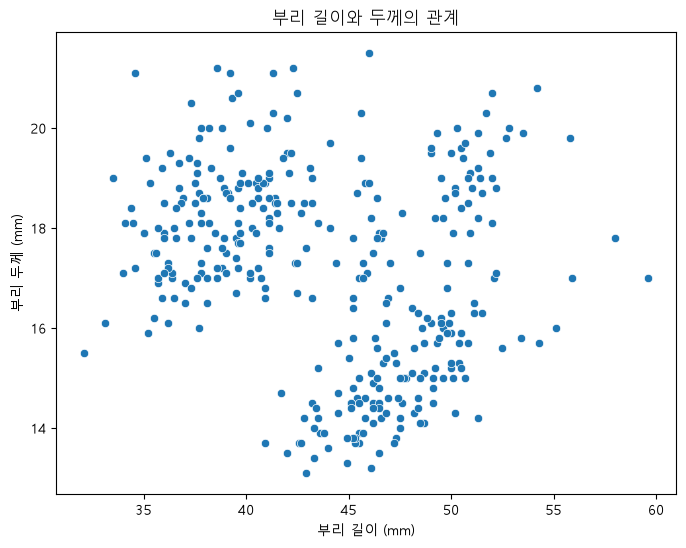

In [4]:
# 문제 1 · Q1
plt.figure(figsize=(8, 6))
sns.scatterplot(data=penguins, x='bill_length_mm', y='bill_depth_mm')
plt.title('부리 길이와 두께의 관계')
plt.xlabel('부리 길이 (mm)')
plt.ylabel('부리 두께 (mm)')
plt.show()

### Q2 · 종별로 색을 나눠 같은 그림을 다시 그려 봅시다

- Q1과 똑같은 산점도에 펭귄의 종(`species`)별로 점의 색을 다르게 칠하세요.

- Q1의 그림과 나란히 놓고 무엇이 달라 보이는지 관찰하세요.

- `💡 힌트` `sns.scatterplot()`에 `hue` 인수를 추가해 보세요.

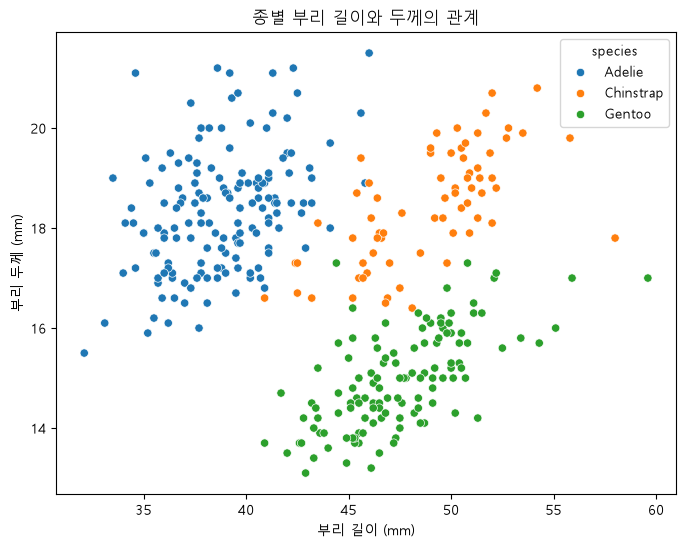

In [5]:
# 문제 1 · Q2
plt.figure(figsize=(8, 6))
sns.scatterplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', hue='species')
plt.title('종별 부리 길이와 두께의 관계')
plt.xlabel('부리 길이 (mm)')
plt.ylabel('부리 두께 (mm)')
plt.show()

### Q3 · 상관계수를 '전체'와 '종별'로 각각 구해 비교해 봅시다

- 두 변수의 상관계수를 **전체 데이터**에 대해 계산하세요.

- 같은 상관계수를 **종별로 나누어** 계산하세요.

- 두 결과의 **부호**를 비교하세요.

- `💡 힌트` 전체는 `df[['A','B']].dropna().corr()`,
  종별은 `df.groupby('species')[['A','B']].corr()`를 활용해 보세요.

In [4]:
# 문제 1 · Q3
# 전체 상관계수
corr_all = penguins[['bill_length_mm', 'bill_depth_mm']].dropna().corr()
print("전체 상관계수:")
print(corr_all)

# 종별 상관계수
corr_by_species = penguins.groupby('species')[['bill_length_mm', 'bill_depth_mm']].corr()
print("\n종별 상관계수:")
print(corr_by_species)

전체 상관계수:
                bill_length_mm  bill_depth_mm
bill_length_mm        1.000000      -0.235053
bill_depth_mm        -0.235053       1.000000

종별 상관계수:
                          bill_length_mm  bill_depth_mm
species                                                
Adelie    bill_length_mm        1.000000       0.391492
          bill_depth_mm         0.391492       1.000000
Chinstrap bill_length_mm        1.000000       0.653536
          bill_depth_mm         0.653536       1.000000
Gentoo    bill_length_mm        1.000000       0.643384
          bill_depth_mm         0.643384       1.000000


### 💬 정리 · 결과를 말로 설명해 보기

- Q1의 산점도에서 두 변수는 어떤 방향의 관계로 보였나요? Q3의 전체 상관계수와 부호가 일치하나요? -> 음의 방향인 것처럼 보였다. 우하향! 일치합니다

- Q3의 종별 상관계수는 전체와 부호가 같나요, 다른가요? -> 다릅니다. 전체는 -, 종별은 +

- **같은 데이터인데 전체와 집단별 결론이 정반대로 나온 이유**를 설명해 보세요. 무엇이 이 착시를 만들고 있나요? -> 군집이 착시를 만들었다

- 만약 이 데이터에 '종' 정보가 없었다면 우리는 어떤 잘못된 결론을 내렸을까요? -> 펭귄부리의 길이와 깊이에 음의 상관관계가 있다고 잘못된 결론을 내렸을 것이다. 

<details>
<summary>(클릭) 💡 생각의 갈피</summary>

- 부호가 뒤집히는 열쇠는 **종마다 부리의 '기본 크기'가 다르다**는 데 있습니다. 종별 평균이 어디에 놓여 있는지를 Q2의 그림에서 확인해 보세요.

- "전체를 보면 음, 나누면 양"은 두 변수 사이에 **숨은 집단 변수**가 끼어 있을 때 나타납니다. 이 현상에는 이름이 붙어 있고, 다음 시간 인과추론에서 다시 만납니다.

- 결론의 형태를 이렇게 나눠 써 보면 정확해집니다 — "종을 무시하면 ○○, 종을 고려하면 ○○".

</details>

In [ ]:
# 문제 1 · 정리
# 여기에 의견을 작성해주세요.

[1번 문제]
- 우하향, 즉 음의 방향인 것처럼 보였다. Q3의 전체 상관계수(-)와 일치한다.

[2번 문제]
- 다르다. 전체는 음(-)의 상관관계지만, 종별로 나누면 세 종 모두 양(+)의 상관관계를 보인다.

[3번 문제]
- 종마다 부리의 '기본 크기'가 다르다는 것이 원인이다. Gentoo는 부리가 길고 얇은 편이고, Adelie와 Chinstrap은 상대적으로 짧고 두꺼운 편이라, 세 종의 점 덩어리가 산점도 위에서 서로 다른 위치에 떨어져 있다. 그래서 종을 무시하고 전체를 보면 이 덩어리들이 우하향으로 늘어선 것처럼 보여 음의 상관관계로 착시가 생기지만, 각 종 안에서만 보면 부리 길이와 두께가 함께 커지는 실제 양의 관계가 드러난다. 즉 종이라는 숨은 집단 변수가 개체 간 관계를 왜곡시킨 것이다.

[4번 문제]
- 종을 무시하면 부리 길이와 두께 사이에 음의 상관관계가 있다는 잘못된 결론을 내렸을 것이다. 종을 고려하면 실제로는 세 종 모두 양의 상관관계를 가진다는 것을 알 수 있다.

## 문제 2 · 날개가 길면 몸무게도 무거울까? — 관계를 숫자로

`난이도 하` · `예상 20분`

**📖 상황**

- 문제 1에서 "숫자 전에 그림"을 배웠습니다. 이제 관계를 **숫자 하나**로 요약해 봅니다.

- 이번에는 **날개 길이(`flipper_length_mm`)와 몸무게(`body_mass_g`)**를 봅니다.
  이 두 변수는 **문제 5까지 계속 사용**하며, 상관 → 회귀 → 검정 → 진단으로 이어집니다.

- **피어슨 상관계수(r)**는 관계의 방향(부호)과 강도(절대값)를 −1~+1로 나타냅니다.
  다만 피어슨은 **두 변수가 정규분포라는 전제**에 기대는 모수적 방법입니다.

**🎯 이 문제로 배우는 것**

- 정규성 점검 → 피어슨(r과 p-값) → 스피어만 비교의 순서로, **강의에서 배운 절차 그대로** 상관을 구합니다.

결측치 제거 전: 344 행
결측치 제거 후: 342 행


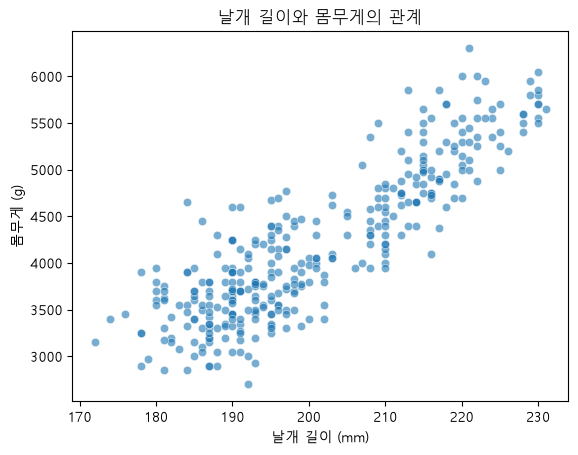

In [6]:
# 문제 2 · 데이터 준비 — 실행만 하세요
df_corr = penguins[['flipper_length_mm', 'body_mass_g']].dropna()

print("결측치 제거 전:", len(penguins), "행")
print("결측치 제거 후:", len(df_corr), "행")

# 두 변수의 관계를 그림으로 먼저 확인 (문제 1의 교훈!)
sns.scatterplot(data=df_corr, x='flipper_length_mm', y='body_mass_g', alpha=0.6)
plt.title("날개 길이와 몸무게의 관계")
plt.xlabel("날개 길이 (mm)")
plt.ylabel("몸무게 (g)")
plt.show()

### Q1 · 피어슨의 전제인 정규성을 점검해 봅시다

- `flipper_length_mm`과 `body_mass_g` **각각**에 대해 정규성 검정(Shapiro-Wilk)을 수행하세요.

- 유의수준 0.05를 기준으로 '정규성을 기각하는지'까지 함께 출력하세요.

- `💡 힌트` `stats.shapiro(데이터)`는 통계량과 p-값을 함께 돌려줍니다.

In [7]:
# 문제 2 · Q1
# flipper_length_mm 정규성 검정
stat1, p1 = stats.shapiro(df_corr['flipper_length_mm'])
print("flipper_length_mm - 통계량:", stat1, ", p-값:", p1)
print("정규성 기각 여부:", "기각 (정규성 X)" if p1 < 0.05 else "기각 못함 (정규성 O)")

print()

# body_mass_g 정규성 검정
stat2, p2 = stats.shapiro(df_corr['body_mass_g'])
print("body_mass_g - 통계량:", stat2, ", p-값:", p2)
print("정규성 기각 여부:", "기각 (정규성 X)" if p2 < 0.05 else "기각 못함 (정규성 O)")

flipper_length_mm - 통계량: 0.9515450641031906 , p-값: 3.5401361704438612e-09
정규성 기각 여부: 기각 (정규성 X)

body_mass_g - 통계량: 0.9592111774906512 , p-값: 3.6790392409769466e-08
정규성 기각 여부: 기각 (정규성 X)


### Q2 · 피어슨 상관계수와 p-값을 함께 구해 봅시다

- 상관계수만이 아니라 **p-값도 함께** 구하세요. 상관계수도 가설검정의 대상입니다.

- 결과는 반드시 `r`, `p_value`라는 이름으로 저장하세요. **문제 3·4에서 이어서 사용합니다.**

- `💡 힌트` `r, p_value = stats.pearsonr(x, y)` — 귀무가설은 "모집단의 상관계수가 0이다"입니다.

In [8]:
# 문제 2 · Q2
r, p_value = stats.pearsonr(df_corr['flipper_length_mm'], df_corr['body_mass_g'])
print("피어슨 상관계수 r:", r)
print("p-값:", p_value)

피어슨 상관계수 r: 0.8712017673060115
p-값: 4.370680962999258e-107


### Q3 · 스피어만 상관계수를 구해 피어슨과 비교해 봅시다

- 스피어만 상관계수(ρ)를 구하세요.

- Q2의 피어슨 값과 **나란히 출력**해 두 값의 차이를 눈으로 확인하세요.

- `💡 힌트` `stats.spearmanr(x, y)`

In [9]:
# 문제 2 · Q3
rho, p_value_s = stats.spearmanr(df_corr['flipper_length_mm'], df_corr['body_mass_g'])
print("스피어만 상관계수 rho:", rho)
print("p-값:", p_value_s)

print()
print("피어슨 r:", r, "vs 스피어만 rho:", rho)

스피어만 상관계수 rho: 0.8399741230312999
p-값: 2.763218997179657e-92

피어슨 r: 0.8712017673060115 vs 스피어만 rho: 0.8399741230312999


### Q4 · 세 결과를 종합해 관계를 문장으로 정리해 봅시다

- Q1~Q3의 결과를 근거로, 오른쪽 빈칸을 채워 관계를 정리하세요.

- 숫자만 적지 말고 **그 숫자가 뜻하는 바**를 함께 쓰세요.

In [ ]:
# 문제 2 · Q4
# 정규성 검정 결과 (피어슨의 전제가 지켜졌나요?): 두 변수 모두 정규성을 만족하지 않음
# 피어슨 r 값과 p-값:0.871 / 4.370680962999258e-107
# 스피어만 ρ 값:0.839 / 2.763218997179657e-92
# 부호(+/-)가 뜻하는 관계의 방향: 양의 관계
# 절대값의 크기가 뜻하는 관계의 강도: 1에 가까울수록 강한 '선형'관계, 0에 가까울수록 약한 선형 관계, 관계의 강도!를 나타내는건아니다

### 💬 정리 · 결과를 말로 설명해 보기

- Q1에서 정규성이 기각되었습니다. 그렇다면 피어슨 상관계수를 쓰면 안 되는 걸까요? Q2와 Q3의 값을 비교해서 판단해 보세요. -> 원칙적으로는 피어슨 상관계수는 두 변수가 모두 정규성을 만족할 때 사용해야하기 때문에 쓰면안됨. 근데 결과만 봤을때에는 비슷해서 써도 될 것 같기도 함. 여기에서는!

- 피어슨과 스피어만이 비슷하게 나왔다는 것은 무엇을 뜻할까요? 만약 두 값이 크게 달랐다면 어떤 상황을 의심해야 할까요?

- Q2의 p-값은 무엇에 대한 검정인가요? "상관계수가 크다"와 "상관계수가 유의하다"는 같은 말인가요? -> 상관이 없다 / 있다에 대한 가설검정에 대응하는 p값이다. 아니다. 

- '날개가 길어지는 것이 몸무게를 무겁게 만드는 **원인**이다'라고 결론 내릴 수 있을까요? **교란변수 / 역인과 / 우연** 세 가지로 나누어 설명해 보세요. -> 상관계수는 둘의 상관관계만 본 것이기 때문에 날개의 길이가 몸무게의 원인이라고는 할 수 없다. 

<details>
<summary>(클릭) 💡 생각의 갈피</summary>

- 정규성이 깨졌을 때 확인할 것은 "쓰면 안 되나"가 아니라 **"결론이 바뀌는가"**입니다. 두 계수가 거의 같다면 전제 위배의 영향이 작다는 뜻이고, 크게 다르면 이상치나 비선형을 의심합니다.

- p-값은 관계의 **크기**가 아니라 **존재**에 대한 답입니다. 표본이 커지면 아주 작은 상관도 유의해집니다 — 두 질문을 분리해서 답해 보세요.

- 인과를 부정하는 세 갈래를 이 데이터에 대입해 보세요. 교란변수 후보는 문제 1에서 이미 만났습니다.

</details>

In [ ]:
# 문제 2 · 정리
# 여기에 의견을 작성해주세요.

[1번 문제]
- 원칙적으로는 두 변수가 모두 정규분포를 만족해야 피어슨을 쓸 수 있으므로, 엄밀히는 사용하면 안 된다. 하지만 정규성이 깨졌을 때 확인해야 할 것은 "써도 되나 안 되나"가 아니라 "결론이 바뀌는가"이다. 피어슨 r(0.871)과 스피어만 ρ(0.839)를 비교하면 두 값이 크게 다르지 않고 거의 비슷하게 나왔다. 이는 정규성 위배가 결론에 미치는 영향이 작다는 뜻이므로, 이번 데이터에서는 피어슨 결과를 참고해도 무리가 없다고 판단할 수 있다.

[2번 문제]
- 두 값이 비슷하다는 것은 정규성 가정을 위배했더라도 그 영향이 크지 않으며, 두 변수 사이의 관계가 이상치나 비선형성에 크게 흔들리지 않는 안정적인 관계임을 의미한다. 반대로 두 값이 크게 달랐다면 데이터에 극단적인 이상치가 있거나, 관계가 선형이 아니라 곡선 형태(비선형)일 가능성을 의심해야 한다.

[3번 문제]
- Q2의 p-값은 "모집단의 상관계수가 0이다(상관이 없다)"라는 귀무가설에 대한 검정이다. 즉 상관관계가 존재하는지에 대한 답이지, 상관관계의 크기에 대한 답이 아니다. 따라서 "상관계수가 크다"와 "유의하다"는 같은 말이 아니다. 표본 크기가 커지면 아주 작은 상관계수도 통계적으로 유의하게 나올 수 있기 때문에, 크기(r 값 자체)와 유의성(p-값)은 반드시 분리해서 판단해야 한다.

[4번 문제]
- 상관계수는 두 변수가 함께 움직이는 정도만 보여줄 뿐, 원인과 결과의 방향은 알려주지 않는다. 따라서 날개 길이가 몸무게의 원인이라고 단정할 수 없다.

    1) 교란변수: 사실 두 변수 모두 '종(species)' 혹은 '개체의 전반적인 크기(체구)'라는 제3의 변수에 의해 함께 커지는 것일 수 있다. 문제 1에서 확인했듯, Gentoo처럼 몸집 자체가 큰 종은 날개도 길고 몸무게도 무겁다. 즉 종이라는 숨은 변수가 둘을 동시에 움직이게 만드는 것일 수 있다.
    2) 역인과: 반대로 몸무게가 무거운 개체가 성장 과정에서 날개도 더 길게 발달했을 가능성도 배제할 수 없다. 즉 인과의 방향이 우리가 가정한 것과 반대일 수도 있다.
    3) 우연: 표본 수가 342개로 적지 않고 r=0.871로 매우 강한 상관을 보이므로 우연일 가능성은 낮지만, 이론적으로는 항상 고려해야 할 가능성 중 하나다.

- 결론적으로, 상관관계는 인과관계의 증거가 될 수 없으며, 날개 길이와 몸무게 사이의 강한 양의 상관은 관찰될 뿐 그 자체로 원인-결과 관계를 증명하지는 않는다.

## 문제 3 · 그 관계를 하나의 식으로 만들 수 있을까?

`난이도 중` · `예상 25분`

**📖 상황**

- 상관계수는 "관계가 얼마나 **강한가**"만 알려주고, "날개가 1mm 길면 몸무게가 **몇 g** 늘어나는가"는
  말해주지 않습니다. 그 답을 주는 것이 **선형회귀(Linear Regression)**입니다.

- 흩어진 점들을 가장 잘 가로지르는 직선 `y = a + bx`를 찾아 관계를 하나의 **식**으로 표현합니다.
  `a`(절편)는 x가 0일 때의 예측값, `b`(기울기)는 **x가 1 늘 때 y가 평균적으로 변하는 양**입니다.

- 그런데 상관과 회귀는 **서로 남이 아닙니다.** 문제 2에서 구한 `r`과
  이번에 구할 기울기·결정계수 사이에는 정확한 관계식이 성립합니다.

**🎯 이 문제로 배우는 것**

- 회귀식을 적합·해석하고, **상관과 회귀가 한 뿌리임을 숫자로 확인**합니다.

In [11]:
# 문제 3 · 데이터 준비 — 실행만 하세요
penguins_cleaned = penguins.dropna(subset=['body_mass_g', 'flipper_length_mm'])

print("분석에 사용할 데이터:", len(penguins_cleaned), "행")
print("문제 2의 df_corr과 동일한가?:", len(penguins_cleaned) == len(df_corr))

분석에 사용할 데이터: 342 행
문제 2의 df_corr과 동일한가?: True


### Q1 · 단순회귀 모델을 적합해 봅시다

- **날개 길이(설명변수) → 몸무게(반응변수)** 회귀 모델을 적합하세요.

- 적합한 모델은 반드시 `model`이라는 이름으로 저장하세요. **문제 4·5에서 이어서 사용합니다.**

- `💡 힌트` `model = smf.ols(formula='body_mass_g ~ flipper_length_mm', data=...).fit()`

In [12]:
# 문제 3 · Q1
model = smf.ols(formula='body_mass_g ~ flipper_length_mm', data=penguins_cleaned).fit()

### Q2 · 분석 결과표를 출력해 봅시다

- 적합한 모델의 요약 결과표를 출력하세요.

- `coef`, `P>|t|`, `R-squared` 열이 각각 어디에 있는지 눈으로 찾아 두세요. 다음 문제들에서 계속 씁니다.

- `💡 힌트` 모델 객체의 `.summary()` 메소드를 사용하세요.

In [13]:
# 문제 3 · Q2
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Wed, 29 Jul 2026   Prob (F-statistic):          4.37e-107
Time:                        14:20:37   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5780.8314    305.81

### Q3 · 회귀식을 완성해 봅시다

- Q2의 결과표에서 **절편**과 **기울기**를 찾아 오른쪽 빈칸을 채우세요.

- 숫자를 옮겨 적은 뒤, 완성된 식을 한 줄로 써 보세요.

In [ ]:
# 문제 3 · Q3
# 절편(a) 값: -5780.8314
# 기울기(b) 값: 49.6856
# 완성된 회귀식 → 몸무게(g) = -5780.8314 + 49.6856 × 날개길이(mm)

### Q4 · 회귀식으로 예측해 봅시다

- 날개 길이가 평균보다 **10mm 더 긴** 펭귄은, 평균적인 펭귄보다 몸무게가 몇 g 더 무거울까요?

- 계산 결과를 단위(g)와 함께 출력하세요.

- `💡 힌트` 기울기 × 10

In [14]:
# 문제 3 · Q4
slope = 49.6856
weight_diff = slope * 10
print(f"날개 길이가 평균보다 10mm 더 길면, 몸무게는 약 {weight_diff:.2f}g 더 무겁다.")

날개 길이가 평균보다 10mm 더 길면, 몸무게는 약 496.86g 더 무겁다.


### Q5 · 상관과 회귀를 잇는 두 관계식을 확인해 봅시다

- 다음 두 식이 실제로 성립하는지 **숫자로** 확인하세요.
  - ① 기울기 = `r` × (y의 표준편차 / x의 표준편차)
  - ② 결정계수 `R²` = `r²` _(단순회귀에서만 성립)_

- 좌변과 우변을 **나란히 출력**해 두 값이 일치하는지 눈으로 확인하세요.

- `💡 힌트` 문제 2 Q2의 `r`을 사용합니다. 표준편차는 `.std(ddof=1)`, 모델의 R²는 `model.rsquared`입니다.

In [15]:
# 문제 3 · Q5
x = penguins_cleaned['flipper_length_mm']
y = penguins_cleaned['body_mass_g']

# ① 기울기 = r × (y의 표준편차 / x의 표준편차)
r_val, _ = stats.pearsonr(x, y)  # 문제 2 Q2의 r
slope_from_r = r_val * (y.std(ddof=1) / x.std(ddof=1))
slope_from_model = model.params['flipper_length_mm']

print("① 기울기 비교")
print("공식으로 구한 기울기:", slope_from_r)
print("모델의 기울기:", slope_from_model)

print()

# ② 결정계수 R² = r²
r_squared_from_r = r_val ** 2
r_squared_from_model = model.rsquared

print("② 결정계수 비교")
print("r² :", r_squared_from_r)
print("모델의 R-squared:", r_squared_from_model)

① 기울기 비교
공식으로 구한 기울기: 49.685566406100094
모델의 기울기: 49.68556640610008

② 결정계수 비교
r² : 0.7589925193571179
모델의 R-squared: 0.7589925193571178


### 💬 정리 · 결과를 말로 설명해 보기

- 기울기(b) 값을 "날개 길이가 ○○할 때 몸무게가 ○○한다"는 문장으로 풀어 써 보세요.

- 절편(a)이 음수로 나왔습니다. 이 숫자를 "날개 길이가 0mm인 펭귄의 몸무게"로 해석해도 될까요? 왜 그럴까요?

- Q5에서 `R² = r²`을 확인했습니다. 그렇다면 설명변수와 반응변수를 서로 바꿔 분석하면 **기울기**와 **R²**는 각각 같을까요, 다를까요?

- 상관계수 `r`은 단위 없는 −1~1 값이고, 기울기 `b`는 'mm당 g'이라는 단위를 가집니다. 회귀가 상관보다 더 알려주는 것은 무엇인가요?

<details>
<summary>(클릭) 💡 생각의 갈피</summary>

- 절편은 **데이터가 존재하는 범위 밖의 값**입니다. 날개 길이 0mm인 펭귄은 우리 데이터에 없습니다 — 회귀식은 관측 범위 안에서만 의미를 갖습니다.

- x와 y를 바꿨을 때를 생각할 때 기준은 **"r은 대칭인가, s_y/s_x는 대칭인가"**입니다. 두 관계식 ①②를 각각 대입해 보면 답이 갈립니다.

- "강도"와 "변화량"의 차이로 정리해 보세요. 보고서에 "1mm당 ○g"을 쓸 수 있는 쪽은 어느 것인가요?

</details>

In [ ]:
# 문제 3 · 정리
# 여기에 의견을 작성해주세요.

[1번 문제]
- 날개 길이가 1mm 길어질 때, 몸무게는 평균적으로 약 49.69g 증가한다.

[2번 문제]
- 해석하면 안 된다. 절편은 회귀식에서 x=0일 때의 예측값이지만, 이는 데이터가 존재하는 범위 밖의 값이다. 실제 데이터의 날개 길이는 172~231mm 범위에 있고, 날개 길이가 0mm인 펭귄은 존재하지 않는다. 회귀식은 관측된 데이터 범위 안에서만 의미를 가지므로, 범위를 벗어난 외삽에 절편을 실제 의미로 해석하면 안 된다. (음수 몸무게라는 것 자체가 현실적으로 불가능하다는 것도 이를 뒷받침한다.)

[3번 문제]
- R²는 같다. 상관계수 r은 x와 y를 바꿔도 값이 동일한 대칭적인 지표이기 때문에, R² = r² 역시 그대로 유지된다.(corr(x,y) = corr(y,x))
- 기울기는 다르다. 기울기 공식 b = r × (y의 표준편차 / x의 표준편차)에서, x와 y를 바꾸면 표준편차의 비율이 뒤집힌다(s_y/s_x → s_x/s_y). 즉 기울기는 대칭이 아니므로 방향을 바꾸면 값이 달라진다.

[4번 문제]
- 상관계수 r은 두 변수 사이 관계의 강도와 방향만 알려주는 무단위 지표다. 반면 회귀의 기울기 b는 실제 단위를 가진 변화량, 즉 "x가 1단위 늘어날 때 y가 실제로 몇 g만큼 변하는가"라는 구체적인 수치를 알려준다. 즉 회귀는 상관보다 더 나아가 예측과 실질적 크기 추정을 가능하게 해준다.

## 문제 4 · 이 기울기, 우연이 아니라고 말할 수 있을까?

`난이도 중` · `예상 25분`

**📖 상황**

- 문제 3에서 기울기를 구했습니다. 그런데 이 값은 **표본 342마리에서 계산된 값**입니다.

- 만약 전체 펭귄 집단에서 두 변수가 실제로는 아무 관계가 없다면(**기울기 = 0**),
  우리가 얻은 기울기는 그저 **표본을 뽑는 과정에서 우연히 생긴 값**일 수도 있습니다.

- 이 의심에 답하는 것이 **회귀계수의 가설검정**이고, 결과표의 `P>|t|` 열이 판단 근거입니다.

**🎯 이 문제로 배우는 것**

- 강의에서 배운 **상관계수의 유의성 검정**과 회귀계수 검정이 **같은 검정**임을 확인하고,
  p-값이 항상 작게 나오는 것은 아니라는 사실을 **기각 실패 사례**로 직접 만납니다.

In [16]:
# 문제 4 · 데이터 준비 — 실행만 하세요
# 문제 3의 Q1을 먼저 완료해야 이 문제를 풀 수 있습니다.

print("분석 대상 데이터:", len(penguins_cleaned), "행 (문제 3과 동일)")
print("설명변수: flipper_length_mm  /  반응변수: body_mass_g")

분석 대상 데이터: 342 행 (문제 3과 동일)
설명변수: flipper_length_mm  /  반응변수: body_mass_g


### Q1 · 가설을 세워 봅시다

- 회귀계수(기울기)에 대한 귀무가설(H₀)과 대립가설(H₁)을 오른쪽 빈칸에 쓰세요.

- '기울기'가 무엇과 같은지/다른지를 명확히 적으세요.

In [ ]:
# 문제 4 · Q1
# H₀ (귀무가설):모집단에서 날개 길이(flipper_length_mm)의 회귀계수(기울기)는 0이다.(= 날개 길이는 몸무게에 영향을 주지 않는다)
# H₁ (대립가설):모집단에서 날개 길이(flipper_length_mm)의 회귀계수(기울기)는 0이 아니다.(= 날개 길이는 몸무게와 관계가 있다)

### Q2 · 기울기의 p-값을 찾아 봅시다

- `flipper_length_mm` 행에서 `P>|t|` 열의 값을 찾아 출력하세요.

- `💡 힌트` 결과표에서 눈으로 찾아도 되고, 모델 객체의 `.pvalues` 속성을 써도 됩니다.

In [17]:
# 문제 4 · Q2
p_slope = model.pvalues['flipper_length_mm']
print("flipper_length_mm 기울기의 p-값:", p_slope)

flipper_length_mm 기울기의 p-값: 4.370680962999914e-107


### Q3 · 유의수준 0.05로 결론을 내려 봅시다

- p-값과 유의수준 `alpha = 0.05`를 비교해, **판정 결과를 문장으로 출력하는 코드**를 작성하세요.

- 숫자만 찍지 말고 "기각한다 / 기각하지 못한다"까지 출력되도록 만드세요.

In [18]:
# 문제 4 · Q3
alpha = 0.05

if p_slope < alpha:
    print(f"p-값({p_slope:.3e})이 유의수준({alpha})보다 작으므로, 귀무가설(H0)을 기각한다.")
    print("→ 날개 길이의 회귀계수(기울기)는 통계적으로 유의하다. 즉, 날개 길이는 몸무게와 유의미한 관계가 있다.")
else:
    print(f"p-값({p_slope:.3e})이 유의수준({alpha})보다 크므로, 귀무가설(H0)을 기각하지 못한다.")
    print("→ 날개 길이의 회귀계수(기울기)가 0이 아니라고 할 만한 충분한 근거가 없다.")

p-값(4.371e-107)이 유의수준(0.05)보다 작으므로, 귀무가설(H0)을 기각한다.
→ 날개 길이의 회귀계수(기울기)는 통계적으로 유의하다. 즉, 날개 길이는 몸무게와 유의미한 관계가 있다.


### Q4 · 상관계수의 검정과 같은 검정인지 확인해 봅시다

- 강의에서 배운 공식으로 t-통계량을 **직접 계산**하세요.

  `t = r × √(n − 2) / √(1 − r²)`

- 이 값을 `model.tvalues['flipper_length_mm']`와 **나란히 출력**해 비교하세요.

- `💡 힌트` `n`은 표본 크기(`len(penguins_cleaned)`), `r`은 문제 2 Q2에서 구한 값입니다.

In [19]:
# 문제 4 · Q4
import numpy as np

n = len(penguins_cleaned)
r = r_val  # 문제 2 Q2에서 구한 피어슨 r

t_calculated = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
t_from_model = model.tvalues['flipper_length_mm']

print("공식으로 계산한 t-통계량:", t_calculated)
print("모델의 t-통계량:", t_from_model)

공식으로 계산한 t-통계량: 32.722233912337416
모델의 t-통계량: 32.7222339123374


### Q5 · p-값이 크게 나오는 사례를 만나 봅시다

- **Adelie 종 수컷만** 골라, `bill_length_mm`으로 `body_mass_g`를 설명하는 회귀를 적합하세요.

- 기울기의 p-값을 유의수준 0.05와 비교하고, 표본 크기(n)와 `R²`도 함께 출력하세요.

- `💡 힌트` 먼저 필요한 열의 결측치를 제거한 뒤 조건으로 걸러 냅니다.
  `df[(df['species'] == 'Adelie') & (df['sex'] == 'Male')]`

In [20]:
# 문제 4 · Q5
# Adelie 종 수컷만 필터링 (필요한 열 결측치 먼저 제거)
adelie_male = penguins.dropna(subset=['bill_length_mm', 'body_mass_g', 'species', 'sex'])
adelie_male = adelie_male[(adelie_male['species'] == 'Adelie') & (adelie_male['sex'] == 'Male')]

# 회귀 모델 적합
model_adelie = smf.ols(formula='body_mass_g ~ bill_length_mm', data=adelie_male).fit()

# 결과 확인
p_slope_adelie = model_adelie.pvalues['bill_length_mm']
n_adelie = len(adelie_male)
r_squared_adelie = model_adelie.rsquared

print("표본 크기(n):", n_adelie)
print("기울기의 p-값:", p_slope_adelie)
print("R-squared:", r_squared_adelie)

alpha = 0.05
if p_slope_adelie < alpha:
    print(f"\np-값({p_slope_adelie:.4f})이 유의수준({alpha})보다 작으므로, 귀무가설을 기각한다.")
    print("→ Adelie 수컷 안에서는 부리 길이가 몸무게와 유의미한 관계가 있다.")
else:
    print(f"\np-값({p_slope_adelie:.4f})이 유의수준({alpha})보다 크므로, 귀무가설을 기각하지 못한다.")
    print("→ Adelie 수컷 안에서는 부리 길이가 몸무게와 유의미한 관계가 있다고 할 근거가 부족하다.")

model_adelie.summary()

표본 크기(n): 73
기울기의 p-값: 0.06100663650006562
R-squared: 0.04856294842469089

p-값(0.0610)이 유의수준(0.05)보다 크므로, 귀무가설을 기각하지 못한다.
→ Adelie 수컷 안에서는 부리 길이가 몸무게와 유의미한 관계가 있다고 할 근거가 부족하다.


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     3.624
Date:                Wed, 29 Jul 2026   Prob (F-statistic):             0.0610
Time:                        14:21:41   Log-Likelihood:                -528.22
No. Observations:                  73   AIC:                             1060.
Df Residuals:                      71   BIC:                             1065.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       2687.8780    713.222      3.769      0.000    1265.755    4110.001
bill_length_mm    33.5628     17.631      1.904      0.061      -1.592      68.717
==============================================================================
Omnibus:                        0.882   Durbin-Watson:                   1.882
Prob(Omnibus):                  0.643   Jarque-Bera (JB):                0.923
Skew:                           0.131   Prob(JB):                        0.630
Kurtosis:                       2.515   Cond. No.                         724.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 💬 정리 · 결과를 말로 설명해 보기

- p-값이 작다는 것은 정확히 무엇이 작다는 뜻인가요? "귀무가설이 참일 확률"이라고 말해도 될까요?

- Q4에서 두 t값이 일치했습니다. 이것은 상관계수의 검정과 회귀계수의 검정이 **어떤 관계**임을 뜻하나요?

- Q5의 결과는 Q2와 어떻게 달랐나요? 같은 `penguins` 데이터인데 결론이 갈린 이유를 **표본 크기**와 **관계의 강도(R²)** 두 측면에서 설명해 보세요.

- Q5처럼 p-값이 0.05보다 조금 큰 경우, "두 변수는 관계가 없음이 증명되었다"고 말할 수 있을까요? 어떻게 말하는 것이 정확할까요?

<details>
<summary>(클릭) 💡 생각의 갈피</summary>

- p-값은 "H₀가 참이라고 **가정했을 때** 이런 결과가 나올 확률"입니다. 가정과 결론의 방향을 뒤집지 않도록 문장을 조심해서 써 보세요.

- Q4의 일치는 우연이 아닙니다. 단순회귀에서는 "두 변수가 무관하다"는 하나의 가설을 두 가지 방식으로 적었을 뿐입니다 — 그래서 t도 p도 같습니다.

- 기각 실패는 **"관계가 없다"가 아니라 "관계가 있다는 증거가 부족하다"**입니다. Q5의 n과 R²를 보면 왜 증거가 부족했는지 짐작할 수 있습니다.

</details>

In [ ]:
# 문제 4 · 정리
# 여기에 의견을 작성해주세요.

[1번 문제]
- p-값은 "귀무가설(H0)이 참이라고 가정했을 때, 지금 관측한 것과 같거나 더 극단적인 결과(t값 또는 상관계수)가 나올 확률"이다. "귀무가설이 참일 확률"이라고 말하면 안 된다. 

[2번 문제]
- 이 일치는 우연이 아니다. 단순회귀(설명변수 1개)에서 "상관계수가 0이다"와 "회귀계수(기울기)가 0이다"는 수학적으로 완전히 동일한 가설이며, 단지 두 가지 다른 방식(상관 분석 vs 회귀 분석)으로 같은 검정을 표현한 것뿐이다. 그래서 t-통계량도, p-값도 정확히 같게 나온다.

[3번 문제]
- Q2에서는 p-값이 4.37e-107로 극도로 작아 뚜렷하게 유의했다. 반면 Q5에서는 p-값이 0.061로 유의수준 0.05를 아주 살짝 넘어 기각하지 못하는 결과가 나왔다. 이 차이는 두 가지로 설명할 수 있을 것 같다. 

    1) 표본 크기: 전체 342마리에서 Adelie 수컷만 걸러내니 표본이 n=73으로 크게 줄었다. 표본이 작아지면 실제로 관계가 있어도 통계적으로 유의하다고 판단할 검정력이 약해진다.
    2) 관계의 강도(R²): Q2에서는 R²=0.759로 매우 강한 관계였지만, Q5에서는 R²=0.049로 매우 약하다. 종과 성별을 하나로 고정하니, 전체 데이터에서 보였던 강한 관계의 상당 부분이 사실 종/성별 간 차이에서 왔던 것이고, 같은 집단(Adelie 수컷) 안에서만 보면 부리 길이와 몸무게 사이의 순수한 관계는 거의 없다시피 약하다는 것을 알 수 있다.

[4번 문제]
- 아니다. p=0.061은 0.05보다 아주 근소하게 클 뿐이며, 이는 "관계가 없다"는 증명이 아니라 "이 작은 표본(n=73)에서는 관계가 있다는 증거가 통계적 기준을 살짝 밑돌 만큼 불충분했다"는 뜻이다. R²=0.049로 실제 관계 자체가 약해 보이긴 하지만, 표본이 더 컸다면 이 정도 크기의 관계도 유의하게 나왔을 가능성이 있다. 

## 문제 5 · 미니 프로젝트 — 이 회귀모형, 믿고 보고해도 될까?

`난이도 상` · `예상 35분`

**📖 상황**

- 계수가 유의하다고 해서 분석이 끝난 것은 아닙니다. 보고서를 쓰기 전에 두 가지를 더 확인합니다.

- **① 얼마나 설명하는가 — 결정계수(R²)**
  반응변수 전체 변동 중 이 모델이 설명한 비율입니다.

- **② 전제가 지켜졌는가 — 잔차(Residual) 진단**
  잔차는 `실제값 − 예측값`입니다. 좋은 모델이라면 잔차가 **패턴 없이 0 주위에 고르게** 흩어져야 합니다.
  깔때기(부채꼴) 모양이면 **등분산성**이 깨졌다는 신호이고, 이때는 p-값과 신뢰구간을 그대로 믿기 어렵습니다.

**🎯 이 문제로 배우는 것**

- 우리 모형을 진단한 뒤, **일부러 문제가 있는 다른 모형과 나란히 놓고 비교**합니다.
  "통과한 잔차"만 보면 진단을 왜 하는지 알 수 없기 때문입니다.

In [21]:
# 문제 5 · 데이터 준비 — 실행만 하세요
# 문제 3의 Q1을 먼저 완료해야 이 문제를 풀 수 있습니다.

print("분석 대상 데이터:", len(penguins_cleaned), "행")
print("모형: body_mass_g ~ flipper_length_mm")

분석 대상 데이터: 342 행
모형: body_mass_g ~ flipper_length_mm


### Q1 · 결정계수로 설명력을 평가해 봅시다

- 모델의 `R-squared` 값을 출력하세요.

- 그 값이 뜻하는 바를 "몸무게 변동의 몇 %" 형태로 오른쪽 빈칸에 쓰세요.

- `💡 힌트` `model.rsquared`

In [22]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Wed, 29 Jul 2026   Prob (F-statistic):          4.37e-107
Time:                        14:24:24   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5780.8314    305.815    -18.903      0.000   -6382.358   -5179.305
flipper_length_mm    49.6856      1.518     32.722      0.000      46.699      52.672
==============================================================================
Omnibus:                        5.634   Durbin-Watson:                   2.176
Prob(Omnibus):                  0.060   Jarque-Bera (JB):                5.585
Skew:                           0.313   Prob(JB):                       0.0613
Kurtosis:                       3.019   Cond. No.                     2.89e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.89e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [24]:
# 문제 5 · Q1
# R-squared 값: 0.759
# 설명력 해석 (몸무게 변동의 몇 %를 설명하나요?): 몸무게 변동의 약 75.9%를 날개 길이가 설명한다

# 문제 5 · Q1
r_squared_model = model.rsquared
print("R-squared 값:", r_squared_model)

R-squared 값: 0.7589925193571178


### Q2 · 예측값과 잔차를 계산해 봅시다

- 모델의 **예측값**과 **잔차**를 각각 계산해 변수에 저장하세요.

- 잔차의 개수와 평균을 함께 출력해, 잔차가 0 주위에 모여 있는지 확인하세요.

- `💡 힌트` 예측값은 `.fittedvalues`, 잔차는 `.resid` 속성입니다.

In [ ]:
# 문제 5 · Q2
predicted = model.fittedvalues
residuals = model.resid

print("잔차 개수:", len(residuals))
print("잔차 평균:", residuals.mean())

잔차 개수: 342
잔차 평균: 2.0609894557719865e-12


### Q3 · 잔차 산점도를 그려 봅시다

- 가로축을 **예측값**, 세로축을 **잔차**로 하는 산점도를 그리세요.

- `y = 0` 기준선을 함께 표시하면 패턴을 보기 쉽습니다.

- `💡 힌트` `plt.scatter()` 와 `plt.axhline(0, color='red', linestyle='--')`

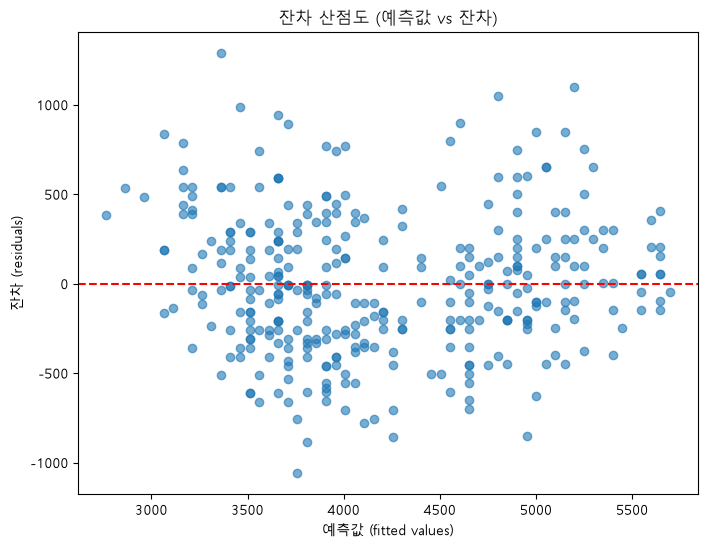

In [26]:
# 문제 5 · Q3
plt.figure(figsize=(8, 6))
plt.scatter(predicted, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('잔차 산점도 (예측값 vs 잔차)')
plt.xlabel('예측값 (fitted values)')
plt.ylabel('잔차 (residuals)')
plt.show()

### Q4 · 등분산성을 숫자로 검정해 봅시다

- **브루쉬-페이건 검정**으로 등분산성을 확인하세요.

- H₀는 "등분산이다"입니다. p-값이 0.05보다 작으면 이분산을 의심합니다.

- 판정 결과를 문장으로 함께 출력하세요.

- `💡 힌트` `het_breuschpagan(잔차, model.model.exog)`는
  `(LM통계량, LM p-값, F통계량, F p-값)`을 돌려줍니다.

In [27]:
# 문제 5 · Q4
from statsmodels.stats.diagnostic import het_breuschpagan

lm_stat, lm_pvalue, f_stat, f_pvalue = het_breuschpagan(residuals, model.model.exog)

print("LM 통계량:", lm_stat)
print("LM p-값:", lm_pvalue)
print("F 통계량:", f_stat)
print("F p-값:", f_pvalue)

alpha = 0.05
if lm_pvalue < alpha:
    print(f"\np-값({lm_pvalue:.4f})이 유의수준({alpha})보다 작으므로, 귀무가설(등분산이다)을 기각한다.")
    print("→ 이분산성이 의심된다. 잔차의 분산이 일정하지 않을 가능성이 있다.")
else:
    print(f"\np-값({lm_pvalue:.4f})이 유의수준({alpha})보다 크므로, 귀무가설(등분산이다)을 기각하지 못한다.")
    print("→ 등분산성 가정에 문제가 없다고 볼 수 있다.")

LM 통계량: 2.157903357758779
LM p-값: 0.14183811083304132
F 통계량: 2.1589060004251177
F p-값: 0.14267023329592188

p-값(0.1418)이 유의수준(0.05)보다 크므로, 귀무가설(등분산이다)을 기각하지 못한다.
→ 등분산성 가정에 문제가 없다고 볼 수 있다.


추가－정규성검정

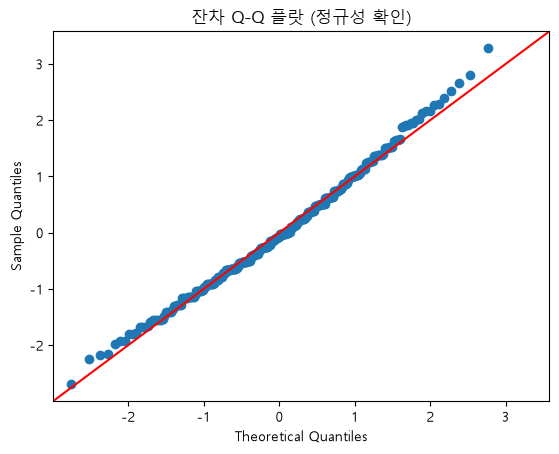

Shapiro-Wilk 통계량: 0.9930134706549084
p-값: 0.11227490486976754
→ p≥0.05, 잔차가 정규분포를 따르지 않는다고 할 근거가 부족하다 (정규성 가정에 문제 없음).


In [29]:
# 잔차 정규성 확인 (Q-Q 플랏 + Shapiro-Wilk)
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats

# Q-Q 플랏
sm.qqplot(residuals, line='45', fit=True)
plt.title('잔차 Q-Q 플랏 (정규성 확인)')
plt.show()

# 숫자로도 확인 (Shapiro-Wilk)
stat, p_value = stats.shapiro(residuals)
print("Shapiro-Wilk 통계량:", stat)
print("p-값:", p_value)

if p_value < 0.05:
    print("→ p<0.05, 잔차가 정규분포를 따르지 않는다는 근거가 있다.")
else:
    print("→ p≥0.05, 잔차가 정규분포를 따르지 않는다고 할 근거가 부족하다 (정규성 가정에 문제 없음).")

### Q5 · 문제가 있는 모형과 나란히 비교해 봅시다

- **비교군**으로 `body_mass_g ~ bill_length_mm` 모형을 적합해 `model_bill`로 저장하세요.

- 두 모형의 잔차 산점도를 **나란히** 그리세요.

- 두 모형의 브루쉬-페이건 p-값을 **함께 출력**해 비교하세요.

- `💡 힌트` `fig, ax = plt.subplots(1, 2, figsize=(12, 4))`로 두 그림을 옆으로 배치할 수 있습니다.

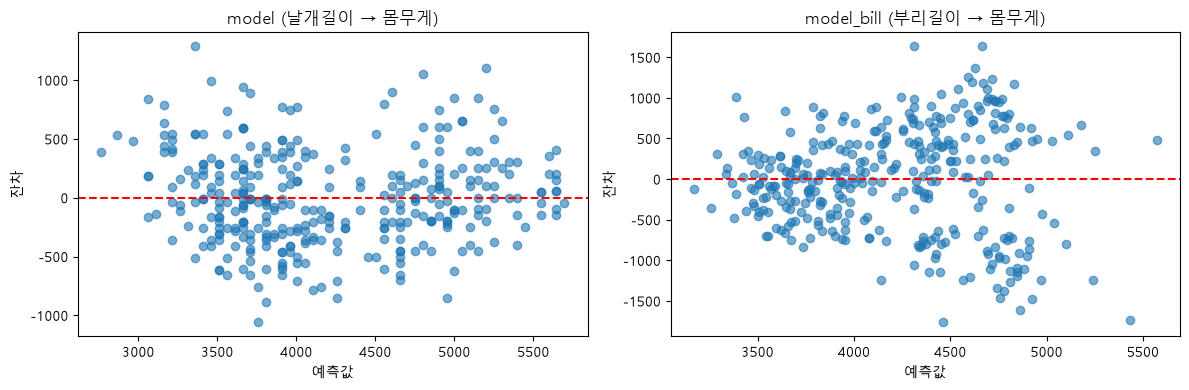

model (flipper_length_mm) 브루쉬-페이건 p-값: 0.14183811083304132
model_bill (bill_length_mm) 브루쉬-페이건 p-값: 9.949024835941186e-19


In [30]:
# 문제 5 · Q5
# 비교군 모형 적합 (전체 데이터, 부리 길이로 몸무게 설명)
model_bill = smf.ols(formula='body_mass_g ~ bill_length_mm', data=penguins_cleaned).fit()

predicted_bill = model_bill.fittedvalues
residuals_bill = model_bill.resid

# 두 모형의 잔차 산점도 나란히
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(predicted, residuals, alpha=0.6)
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_title('model (날개길이 → 몸무게)')
ax[0].set_xlabel('예측값')
ax[0].set_ylabel('잔차')

ax[1].scatter(predicted_bill, residuals_bill, alpha=0.6)
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title('model_bill (부리길이 → 몸무게)')
ax[1].set_xlabel('예측값')
ax[1].set_ylabel('잔차')

plt.tight_layout()
plt.show()

# 두 모형의 브루쉬-페이건 p-값 비교
lm_stat_bill, lm_pvalue_bill, f_stat_bill, f_pvalue_bill = het_breuschpagan(residuals_bill, model_bill.model.exog)

print("model (flipper_length_mm) 브루쉬-페이건 p-값:", lm_pvalue)
print("model_bill (bill_length_mm) 브루쉬-페이건 p-값:", lm_pvalue_bill)

### Q6 · 보고 문장으로 정리해 봅시다

- 지금까지의 결과를 종합해, 우리 회귀모형을 보고서에 어떻게 적을지 **한 문장**으로 쓰세요.

- **기울기 + 유의성 + 설명력 + 진단 결과**를 모두 담아 보세요.

In [ ]:
# 문제 5 · Q6
# 보고 문장:
#    "펭귄의 날개 길이(flipper_length_mm)는 몸무게(body_mass_g)와 통계적으로 유의한 양의 관계를 가지며(β=49.69, p<0.001), "
#    "이 모델은 몸무게 변동의 약 75.9%(R²=0.759)를 설명한다. "
#    "잔차는 0 주위에 고르게 분포하고 브루쉬-페이건 검정 결과 등분산성을 만족했으며, "
#    "정규성 검토(Q-Q 플랏, Shapiro-Wilk) 또한 위배되지 않아 회귀 결과(계수와 신뢰구간)를 신뢰할 수 있다."

### 💬 정리 · 결과를 말로 설명해 보기

- Q3·Q4에서 우리 모형의 잔차는 어떤 상태였나요? 이 결과를 근거로 문제 3·4의 해석을 신뢰할 수 있을까요?

- Q5의 두 잔차 산점도는 어떻게 달랐나요? 비교군에서 관찰된 모양을 강의에서 배운 용어로 무엇이라 부르나요?

- 비교군처럼 등분산성이 깨졌을 때, **잘못된 것은 기울기 값 자체인가요, 아니면 그 값의 통계적 해석인가요?**

- R²가 1이 아니라는 것은 설명되지 않은 변동이 남아 있다는 뜻입니다. `penguins` 안에서 몸무게에 영향을 줄 만한데 우리 모델이 놓치고 있는 변수는 무엇일까요?

- 그 변수들을 모델에 함께 넣으려면 어떤 분석이 필요할까요?

<details>
<summary>(클릭) 💡 생각의 갈피</summary>

- 강의 7장은 이렇게 적었습니다 — _"파라미터 값이 잘못되었다는 뜻이 아니라, 이 값의 통계적 해석(유의성·신뢰구간)과 예측 결과를 신뢰할 수 없다는 의미"_. 세 번째 질문의 답이 여기 있습니다.

- 비교군의 잔차가 퍼지는 모양을 강의의 3케이스 그림(정규성 O·등분산 O / X·O / O·X)과 맞춰 보세요.

- 놓친 변수 후보는 문제 1의 그림에 이미 있습니다. 그 변수를 모델에 함께 넣는 분석의 이름은 다음 8장의 제목입니다.

</details>

In [ ]:
# 문제 5 · 정리
# 여기에 의견을 작성해주세요.

[1번 문제]
- model의 잔차는 0 주위에 특별한 패턴 없이 고르게 흩어져 있었고, 브루쉬-페이건 검정에서도 등분산성 가정이 기각되지 않았다. 따라서 문제 3에서 구한 회귀계수(기울기 49.69)와 문제 4의 유의성 검정(p<0.001) 결과는 신뢰할 수 있다.

[2번 문제]
- model의 잔차는 예측값 전 구간에서 폭이 비교적 일정했다. 반면 그 옆 그래프에서는（부리길이 관련）잔차가 예측값이 커질수록(또는 특정 구간에서) 흩어짐의 폭이 넓어지는 깔때기(부채꼴) 모양을 보였다. -등분산성 위배

[3번 문제]
- 기울기 값 자체가 잘못된 것은 아니다. 등분산성이 깨져도 OLS 추정량은 여전히 불편추정량이다. 잘못되는 것은 그 값의 통계적 해석이다. 즉 등분산성이 위배되면 표준오차 계산이 왜곡되어, 그로부터 나온 유의성 검정(p-값)과 신뢰구간을 그대로 신뢰할 수 없게 된다. 

[4번 문제]
- 종(species)이다. 문제 1의 산점도에서 이미 확인했듯, Gentoo/Adelie/Chinstrap은 몸집(부리 크기, 날개 길이, 몸무게)이 서로 다른 기본값을 가진 별개의 집단이다. 날개 길이 하나만으로는 이 종 간 차이를 반영하지 못하기 때문에, 종이라는 변수가 설명하지 못한 변동의 상당 부분을 차지할 가능성이 높다. 

[5번 문제]
- 다중회귀분석이 필요하다. 날개 길이 외에 종(species), 성별(sex) 등 범주형 변수를 더미변수(One-Hot Encoding)로 변환해 함께 설명변수로 넣으면, 각 변수가 몸무게에 미치는 개별적인 영향을 통제하면서 동시에 추정할 수 있을 것이다

In [23]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


penguins.info()